In [16]:
import sys
sys.path.append('..')
import simpy
from SimPyABM.ChargingColumn import ChargingColumn
from SimPyABM.Vehicle import Vehicle
from SimPyABM.Environment import Environment
from SimPyABM.EnergySandbox import EnergySandbox
import numpy as np
import matplotlib.pyplot as plt
import datetime
import pandas as pd
from SimPyABM.Config import load_config
from SimPyABM.DataProvider import DataProvider

In [17]:
# only load if not already loaded
if 'data_provider' not in globals():
    global data_provider
    data_provider = DataProvider()

In [18]:
config = load_config("../SimPyABM/config.yaml")

In [19]:
simpy_env = simpy.Environment()

In [20]:
# does not need re-start
energy_sandbox = EnergySandbox(simpy_env, config.energy_grid_max_power, config.energy_grid_max_power_PV, data_provider)

In [21]:
env = Environment(simpy_env, energy_sandbox, config)

In [22]:
ch_i = 0
charging_columns = []
strategy = config.charging_strategy
for _ in range(config.num_fast_chg_cols):
    charging_columns.append(ChargingColumn(ch_i, config.fast_chg_cols_ports, config.time_resolution, config.handshake_duration_min, config.handshake_duration_max, config.fast_chg_cols_power, env))
    ch_i += 1
for _ in range(config.num_slow_chg_cols):
    charging_columns.append(ChargingColumn(ch_i, config.slow_chg_cols_ports, config.time_resolution, config.handshake_duration_min, config.handshake_duration_max, config.slow_chg_cols_power, env))
    ch_i += 1
for charging_column in charging_columns:
    env.simpy_env.process(charging_column.main_loop(strategy=strategy))

In [23]:
num_vehicles = env.rng.integers(config.num_vehicles_per_day_min, config.num_vehicles_per_day_max + 1, size=(config.duration_days, ))
v_id = 0
vehicles = []
for day in range(config.duration_days):
    print(f"Simulating day {day + 1} with {num_vehicles[day]} vehicles")
    for _ in range(num_vehicles[day]):
        BAT_CAP = config.car_bat_cap_min + env.rng.random() * (config.car_bat_cap_max - config.car_bat_cap_min)
        SoC = config.SoC_init_min + (config.SoC_init_max - config.SoC_init_min) * env.rng.random()
        bat_max_voltage = config.bat_max_voltages[0] if env.rng.random() > config.bat_voltage_mix else config.bat_max_voltages[1]
        bat_min_voltage = config.bat_min_voltages[0] if env.rng.random() > config.bat_voltage_mix else config.bat_min_voltages[1]
        enter_delay = env.rng.random() * config.ev_enter_max_delay + day * 24 * 3600
        park_duration = config.park_time_min + env.rng.random() * (config.park_time_max - config.park_time_min)
        wait_duration = config.ev_wait_time_min + env.rng.random() * (config.ev_wait_time_max - config.ev_wait_time_min)
        vehicle = Vehicle(v_id, SoC, config.TTR_min, BAT_CAP, bat_max_voltage, bat_min_voltage, env, enter_delay, park_duration, wait_duration)
        vehicles.append(vehicle)
        v_id += 1
        env.simpy_env.process(vehicle.plug_in(charging_columns))
env.simpy_env.process(energy_sandbox.pv_power_adjustment_process(env))

Simulating day 1 with 84 vehicles
Simulating day 2 with 86 vehicles
Simulating day 3 with 70 vehicles
Simulating day 4 with 86 vehicles
Simulating day 5 with 79 vehicles


<Process(pv_power_adjustment_process) object at 0x1c6e3c816d0>

In [24]:
import time
tic = time.time()
env.simpy_env.run(config.duration)

for charging_column in charging_columns:
    charging_column.final_logging()

  # Run the simulation
print(f"Simulation time: {time.time() - tic} seconds")

Simulation time: 0.6346228122711182 seconds


In [25]:
df = env.logger.to_df()
print(df.head())

           time agent         field     value field2 value2
0  1.686024e+09   env  energy_price   0.10062   None   None
1  1.686025e+09   env  energy_price  0.100597   None   None
2  1.686026e+09   env  energy_price  0.100497   None   None
3  1.686028e+09   env  energy_price   0.11991   None   None
4  1.686029e+09   env  energy_price  0.119793   None   None


In [26]:
df = env.logger.to_df()

num_vehicles = np.sum(num_vehicles)
num_chargers = config.num_fast_chg_cols + config.num_slow_chg_cols
sim_days = config.duration_days
if num_vehicles < 50 and num_chargers < 50 and sim_days < 50:
    HEAVY_COMPUTATION = False
else:
    HEAVY_COMPUTATION = True

Initial SoC: [74.54, 76.35, 80.77, 82.7, 79.03, 80.99, 79.06, 83.51, 80.84, 77.77, 80.13, 82.48, 74.01, 75.88, 75.4, 76.79, 82.9, 77.99, 74.39, 82.86, 77.76, 81.25, 78.77, 79.25, 75.91, 74.47, 74.66, 78.88, 74.93, 78.18, 75.02, 75.04, 82.8, 74.62, 77.73, 83.3, 74.71, 77.32, 74.67, 82.04, 81.83, 77.43, 80.79, 75.58, 74.61, 79.84, 81.35, 80.54, 76.54, 81.99, 79.22, 74.72, 81.92, 77.8, 82.84, 75.89, 80.5, 78.53, 77.06, 75.65, 81.87, 83.56, 78.58, 79.32, 79.2, 82.7, 74.41, 74.46, 79.38, 78.54, 78.04, 81.11, 76.93, 77.98, 76.76, 75.03, 74.17, 78.56, 74.02, 74.72, 77.43, 79.47, 75.3, 74.11, 80.62, 78.55, 79.62, 79.14, 76.15, 82.42, 75.32, 79.97, 75.56, 82.44, 80.02, 74.56, 77.52, 81.56, 78.73, 79.77, 80.15, 77.43, 78.81, 80.81, 74.3, 81.8, 74.57, 74.23, 82.06, 77.33, 76.23, 81.21, 74.83, 81.97, 78.69, 74.34, 76.0, 79.89, 80.04, 76.42, 74.56, 80.65, 78.73, 78.04, 83.2, 78.82, 75.22, 79.59, 83.13, 74.98, 76.09, 76.65, 76.83, 77.39, 76.96, 78.31, 83.84, 79.5, 83.51, 76.68, 76.37, 80.95, 82.83, 

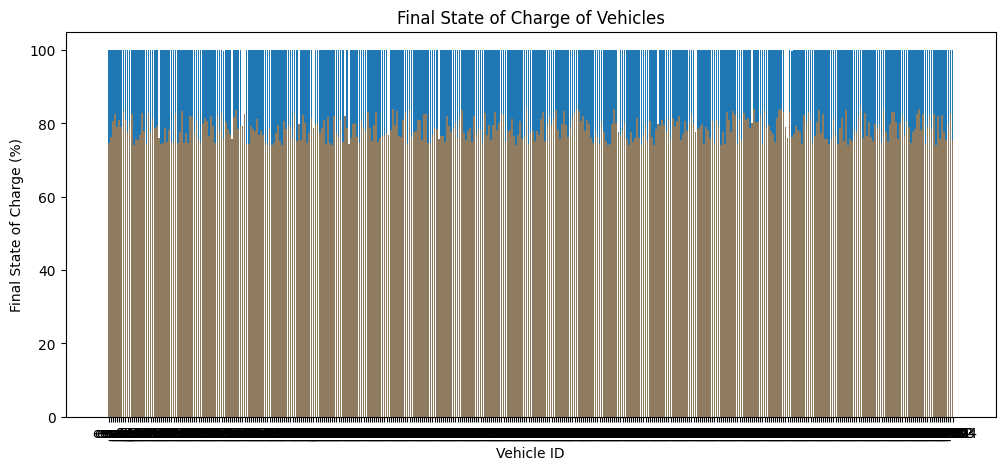

In [27]:
if not HEAVY_COMPUTATION or True:
    plt.figure(figsize=(12, 5))
    df_ev = df[df['agent'].str.contains('ev')].copy()
    df_ev['agent_id'] = df_ev['agent'].apply(lambda x: int(x.split('_')[1]))
    # sort by agent id
    df_ev = df_ev.sort_values(by=['agent_id', 'field', 'value'])
    # find all values of final_SoC
    df_final_SoC = df_ev[df_ev['field'] == 'final_SoCp'][['agent', 'value']]
    ids = df_final_SoC['agent'].tolist()
    x = range(len(ids))
    SoCs = df_final_SoC['value'].tolist()
    plt.bar(x, SoCs)
    df_initial_SoC = df_ev[df_ev['field'] == 'initial_SoCp'][['agent', 'value']]
    initial_SoCs = df_initial_SoC['value'].tolist()
    plt.bar(x, initial_SoCs, alpha=0.5)
    print(f"Initial SoC: {initial_SoCs}")
    print(f"Final SoC: {SoCs}")
    print(f"min final SoC: {min(SoCs)}")
    plt.xticks(x, ids)
    plt.xlabel('Vehicle ID')
    plt.ylabel('Final State of Charge (%)')
    plt.title('Final State of Charge of Vehicles')

In [28]:
if not HEAVY_COMPUTATION:
    charger_marker = {
        -1: "o", 0: "s", 1: "^", 2: "+", 3: "_", 4: "v",
        5: "<", 6: ">", 7: "d", 8: "D", 9: "x",
        10: "*", 11: "p", 12: "h", 13: "H",
        14: "1", 15: "2", 16: "3", 17: "4", 18: "|",
    }

    color_map = plt.get_cmap("tab20")

    plt.figure(figsize=(20, 10))

    for ev_idx, vehicle in enumerate(vehicles):
        data = env.logger.get_field12_data(
            f'ev_{vehicle.id}', "SoC", "charger_id", True
        )

        dt = [datetime.datetime.fromtimestamp(x[0]) for x in data]
        v1 = [x[1] for x in data]   # SoC
        v2 = [x[2] for x in data]   # charger id

        # fixed color per EV
        ev_color = color_map(ev_idx % color_map.N)

        # plot line (color = EV)
        plt.plot(dt, v1, color=ev_color, label=f"EV {vehicle.id}")

        # plot markers (shape = charger, color = charger)
        for charger_id in set(v2):
            idx = [i for i, c in enumerate(v2) if c == charger_id]

            charger_color = color_map(charger_id % color_map.N)

            plt.scatter(
                [dt[i] for i in idx],
                [v1[i] for i in idx],
                marker=charger_marker[charger_id%(len(charger_marker)-1)],
                color=charger_color,
                s=50,
            )

    plt.gcf().autofmt_xdate()
    plt.grid(True)
    plt.xlabel("Time")
    plt.ylabel("SoC (kWh)")

    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=3,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

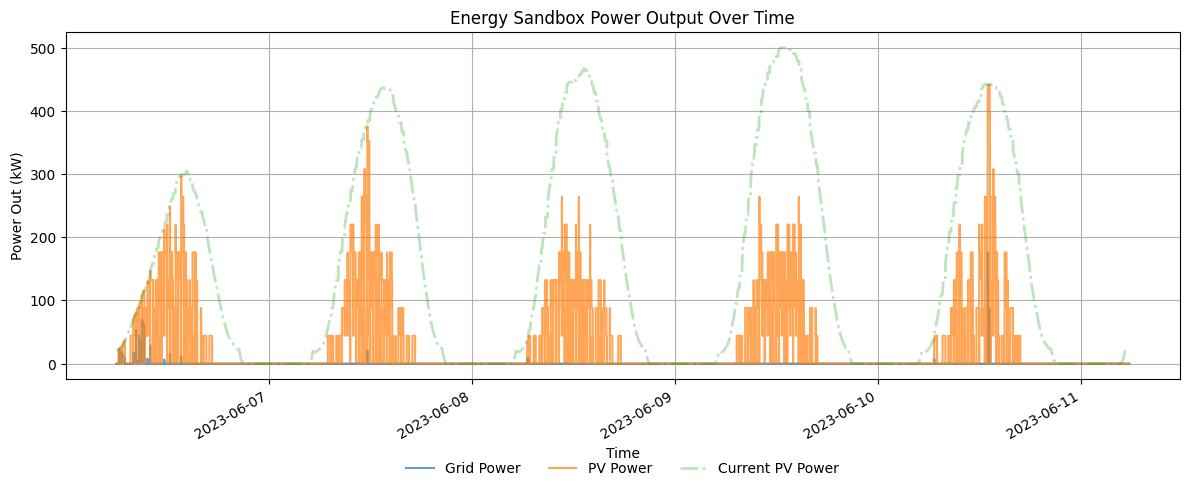

In [29]:
# plot energy sandbox power over time from df
df_energy = df[(df['agent'] == 'energy_sandbox') & (df['field'] == 'power_output_grid_kW')].copy()
# sort by timestamp
df_energy = df_energy.sort_values(by=['time'])
x = df_energy['time'].tolist()
y = df_energy['value'].tolist()
dt = [datetime.datetime.fromtimestamp(x) for x in x]

# PV
df_energy_pv = df[(df['agent'] == 'energy_sandbox') & (df['field'] == 'power_output_PV_kW')].copy()
# sort by timestamp
df_energy_pv = df_energy_pv.sort_values(by=['time'])
x_pv = df_energy_pv['time'].tolist()
y_pv = df_energy_pv['value'].tolist()
dt_pv = [datetime.datetime.fromtimestamp(x) for x in x_pv]

# total
df_energy_total = df[(df['agent'] == 'energy_sandbox') & (df['field'] == 'power_output_kW')].copy()
# sort by timestamp
df_energy_total = df_energy_total.sort_values(by=['time'])
x_total = df_energy_total['time'].tolist()
y_total = df_energy_total['value'].tolist()
dt_total = [datetime.datetime.fromtimestamp(x) for x in x_total]

# current PV power
df_energy_pv_current = df[(df['agent'] == 'energy_sandbox') & (df['field'] == 'current_pv_power_kW')].copy()
# sort by timestamp
df_energy_pv_current = df_energy_pv_current.sort_values(by=['time'])
x_pv_current = df_energy_pv_current['time'].tolist()
y_pv_current = df_energy_pv_current['value'].tolist()
dt_pv_current = [datetime.datetime.fromtimestamp(x) for x in x_pv_current]

plt.figure(figsize=(12, 5))
plt.plot(dt, y, label='Grid Power', alpha=0.7)
plt.plot(dt_pv, y_pv, label='PV Power', alpha=0.7)
plt.plot(dt_pv_current, y_pv_current, label='Current PV Power', alpha=0.3, linestyle='-.', linewidth=2)
#plt.plot(dt_total, y_total, label='Total Power', alpha=0.3, linestyle='--', linewidth=2)
plt.gcf().autofmt_xdate()
# plt.ylim(0, config.energy_grid_max_power)
plt.xlabel('Time')
plt.ylabel('Power Out (kW)')
plt.title('Energy Sandbox Power Output Over Time')
plt.grid(True)
# place legend bottom center, outside of plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

In [30]:
# save df to csv
csv_name = f"{config.expriment_name}_seed_{config.random_seed:05d}_days_{config.duration_days:03d}_strategy_{config.charging_strategy}_EVsMAX_{config.num_vehicles_per_day_max:03d}_CHGF_{config.num_fast_chg_cols:02d}_CHGS_{config.num_slow_chg_cols:02d}_maxGrid_{config.energy_grid_max_power:04d}"
df.to_csv(f"../results/{csv_name}.csv", index=False)